# Auditing the labels: when most of the dataset isn't what it claims

**A reproducible, self-contained demonstration.**

This notebook recreates a real problem: I was handed a labeled panel of samples, and before
using them I checked whether each sample actually was what its label said. It wasn't. Most
of the samples labeled one way were, by their own measured features, a different type
entirely.

**The data here is fully synthetic.** I simulate a panel from a known ground truth so you
can watch a simple classifier catch the mislabeling. Nothing here comes from the original
study; the method and the lesson are what transfer, and they apply to any labeled dataset
you did not generate yourself.

**The setup.** A panel of 36 "cell lines," each with an expression profile over 363 genes,
63 of which are curated identity markers (21 for each of three cell types: epithelial,
fibroblast, immune).

| group | label on the tin | ground truth |
|---|---|---|
| 11 reference lines | known identity (the controls) | as labeled, except one drifted line |
| 25 patient-derived lines | all labeled *epithelial* | 24 are actually fibroblast, 1 is epithelial |

The naive analyst trusts the labels and runs a tumor-epithelial analysis on 25 samples, 24
of which are fibroblasts. Watch a marker-based classifier refuse to go along with it.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
})
rng = np.random.default_rng(11)

C = {"epithelial": "#2a6f4e", "fibroblast": "#8a6bbf",
     "immune": "#9aa0a6", "pdx": "#c0603a"}

## 1. Simulate a labeled panel from known truth

Each cell type turns on its own set of marker genes. A reference line matches its label. The
patient-derived lines are all *labeled* epithelial, but I plant the truth I want to recover:
24 of 25 are fibroblast. One reference line is deliberately drifted toward fibroblast, the
kind of contaminated or mis-passaged sample that should get flagged rather than trusted.


In [2]:
lineages = ["epithelial", "fibroblast", "immune"]
markers_per, n_background = 21, 300          # 21 x 3 = 63-marker panel + background genes
marker_idx = {L: list(range(i*markers_per, (i+1)*markers_per)) for i, L in enumerate(lineages)}
n_markers = markers_per * len(lineages)
n_genes = n_markers + n_background

def profile(lineage, mix=None):
    # expected expression vector: a lineage's markers ON, others at background.
    # mix = list of (lineage, weight) to build a drifted / contaminated line.
    vec = rng.lognormal(mean=4.0, sigma=0.5, size=n_genes)          # background
    def turn_on(L, weight):
        on = marker_idx[L]
        vec[on] *= rng.lognormal(mean=2.3, sigma=0.3, size=len(on)) * weight
    if mix is None:
        turn_on(lineage, 1.0)
    else:
        for L, w in mix:
            turn_on(L, w)
    return vec

def sequence(mean_vec, cv=0.25):               # add biological noise
    shape = 1.0 / cv**2
    return rng.gamma(shape, mean_vec / shape)

records = []   # (id, label, true_identity, expression)
# 11 controls; one epithelial-labeled control is actually drifted toward fibroblast
ref_plan = ([("epithelial", None)]*3
          + [("epithelial", [("epithelial", 0.65), ("fibroblast", 0.9)])]    # drifted / contaminated
          + [("fibroblast", None)]*4
          + [("immune", None)]*3)
for i, (ident, mix) in enumerate(ref_plan):
    vec = sequence(profile(ident if mix is None else None, mix=mix))
    records.append((f"ref_{i+1:02d}", f"reference:{ident}",
                    ident if mix is None else "drifted", vec))

# 25 patient-derived lines, all LABELED epithelial; truly 24 fibroblast + 1 epithelial
pd_truth = ["fibroblast"]*24 + ["epithelial"]*1
rng.shuffle(pd_truth)
for i, true in enumerate(pd_truth):
    records.append((f"pdx_{i+1:02d}", "patient_derived", true, sequence(profile(true))))

sample_ids = [r[0] for r in records]
labels     = np.array([r[1] for r in records])
truth      = np.array([r[2] for r in records])
X = np.array([r[3] for r in records]).T        # genes x samples
print(f"panel: {X.shape[1]} lines, {X.shape[0]} genes, {n_markers} identity markers")

panel: 36 lines, 363 genes, 63 identity markers


## 2. Build the composite marker classifier

Three design choices that matter. **Orthogonal to the label:** the classifier reads the
marker genes, not the paperwork the label came from. **Composite, not single-marker:** each
call is a mean over 21 markers, so no one gene can carry a verdict. **Confidence-aware:** the
margin between the top score and the runner-up tells us when a sample is ambiguous and
should be flagged instead of trusted.


In [3]:
# within-sample signature: log-transform, then center each sample by its own mean.
# this makes an identity score independent of how many similar cells are in the panel,
# so common and rare cell types are scored on the same footing.
logX = np.log2(X + 1.0)
rel = logX - logX.mean(0, keepdims=True)               # center within each sample

# signature score per cell type = mean relative expression over that type's markers
sig = pd.DataFrame({L: rel[marker_idx[L]].mean(0) for L in lineages}, index=sample_ids)

call = sig.idxmax(1)                                   # assign to highest-scoring type
top2 = np.sort(sig.values, axis=1)[:, -2:]
confidence = top2[:, 1] - top2[:, 0]                   # margin: top minus runner-up
flagged = confidence < 0.5                             # low margin = ambiguous identity

res = pd.DataFrame({"label": labels, "true": truth, "call": call.values,
                    "confidence": confidence.round(2), "flagged": flagged},
                   index=sample_ids)
res.head(4)

,label,true,call,confidence,flagged
ref_01,reference:epithelial,epithelial,epithelial,3.53,False
ref_02,reference:epithelial,epithelial,epithelial,3.10,False
ref_03,reference:epithelial,epithelial,epithelial,2.75,False
ref_04,reference:epithelial,drifted,fibroblast,0.48,True


## 3. Validate on the controls first

Never trust an auditor you haven't audited. Run the classifier on the reference lines, whose
identities are known, and check how often it agrees. This confirms the method works and
turns any disagreement into a signal rather than a bug.


control concordance: 10/11 = 91%
flagged as ambiguous: ['ref_04']

the one disagreement (a drifted line, correctly caught):
          expected        call  confidence  flagged
ref_04  epithelial  fibroblast        0.48     True


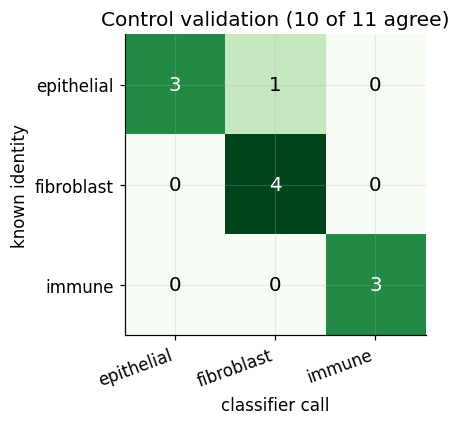

In [4]:
ctrl = res[res.label.str.startswith("reference")].copy()
ctrl["expected"] = [l.split(":")[1] for l in ctrl.label]
concordant = int((ctrl.call == ctrl.expected).sum())
print(f"control concordance: {concordant}/{len(ctrl)} = {concordant/len(ctrl):.0%}")
print("flagged as ambiguous:", list(ctrl.index[ctrl.flagged]))
print("\nthe one disagreement (a drifted line, correctly caught):")
print(ctrl[ctrl.call != ctrl.expected][["expected", "call", "confidence", "flagged"]])

# confusion matrix on controls
conf = pd.crosstab(ctrl.expected, ctrl.call).reindex(index=lineages, columns=lineages, fill_value=0)
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(conf.values, cmap="Greens")
ax.set_xticks(range(3)); ax.set_xticklabels(lineages, rotation=20, ha="right")
ax.set_yticks(range(3)); ax.set_yticklabels(lineages)
ax.set_xlabel("classifier call"); ax.set_ylabel("known identity")
ax.set_title("Control validation (10 of 11 agree)")
for i in range(3):
    for j in range(3):
        v = conf.values[i, j]
        ax.text(j, i, v, ha="center", va="center",
                color="white" if v > conf.values.max()/2 else "black", fontsize=13)
plt.tight_layout(); plt.show()

The classifier reproduces 10 of 11 known identities. The single disagreement is the drifted
line, which it both miscalls relative to its label and flags as low-confidence. That is
exactly the behavior you want: the method is trustworthy, and it tells you when a sample is
not.

## 4. The reveal: audit the patient-derived labels

Now point the validated classifier at the 25 lines that all carry the same label,
*epithelial*, and see what they actually are.


In [5]:
pdx = res[res.label == "patient_derived"]
print("25 lines LABELED epithelial. Classifier calls:")
print(pdx.call.value_counts().to_string())
discordant = (pdx.call != "epithelial").mean()
print(f"\ndisagreement with the label: {discordant:.0%} of the 'epithelial' panel is not epithelial")

25 lines LABELED epithelial. Classifier calls:
call
fibroblast    24
epithelial     1

disagreement with the label: 96% of the 'epithelial' panel is not epithelial


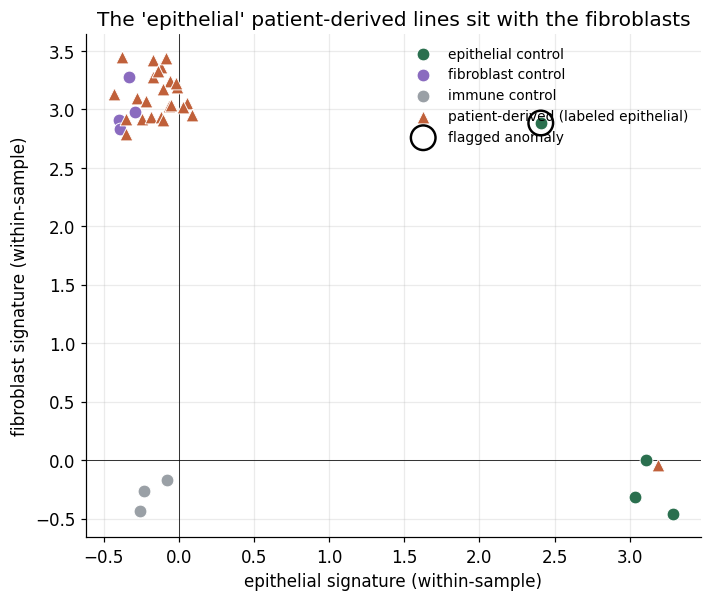

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 5.6))
style = {
    "reference:epithelial": ("epithelial control", C["epithelial"], "o"),
    "reference:fibroblast": ("fibroblast control", C["fibroblast"], "o"),
    "reference:immune":     ("immune control",     C["immune"],     "o"),
    "patient_derived":      ("patient-derived (labeled epithelial)", C["pdx"], "^"),
}
for lab, (name, col, mk) in style.items():
    m = res.label == lab
    ax.scatter(sig.loc[m, "epithelial"], sig.loc[m, "fibroblast"],
               c=col, marker=mk, s=70, edgecolor="white", linewidth=0.6, label=name, zorder=3)
# ring the flagged anomaly
fm = res.flagged.values
ax.scatter(sig.loc[fm, "epithelial"], sig.loc[fm, "fibroblast"], s=260,
           facecolors="none", edgecolors="black", linewidths=1.6, label="flagged anomaly", zorder=4)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("epithelial signature (within-sample)")
ax.set_ylabel("fibroblast signature (within-sample)")
ax.set_title("The 'epithelial' patient-derived lines sit with the fibroblasts")
ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

Every orange triangle is a line labeled epithelial. Almost all of them land in the high
fibroblast, low epithelial quadrant, clustered with the purple fibroblast controls, not with
the green epithelial ones. One triangle sits in the epithelial region, the single line whose
label was correct. The label was wrong for 24 of the 25.

## 5. The transferable lesson

Before you model, audit your labels with something orthogonal to how they were assigned. A
classifier makes an excellent label auditor when you build it from features the label did not
come from, validate it on examples whose truth you already know, and score with a composite
so no single feature can fool it. Add a confidence margin and you get anomaly flags for free.

The payoff is asymmetric. The audit here is a few dozen lines of code. Skipping it means
every downstream conclusion describes fibroblasts while claiming to describe tumor cells, and
no amount of careful modeling after that point can undo a wrong label underneath it.
